## Best Volatile

Identify the stocks which changes a lot in last 3 weeks. We can get in at the max drop.

In [189]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col,dayofweek,current_date,date_sub,to_date,abs,lit
from pyspark.sql.functions import sum as spark_sum,max as spark_max, min as spark_min
from datetime import datetime, timedelta
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

In [190]:
# Get date threshold (last 3 weeks)
date_threshold = datetime.today() - timedelta(weeks=3)
date_threshold_start = datetime.today()
date_threshold_end = datetime.today() + timedelta(weeks=3)

In [191]:

current_dir = os.getcwd()  # Gets /Users/.../practice/finance
pyspark_path = current_dir.split('pyspark')[0] + 'pyspark'  # Gets the path up to 'pyspark'
config_path = os.path.join(pyspark_path, 'conf', 'config.ini')

print(config_path)


/Users/gaurav/workspace/datascience/chatgpt/tensorflow/recomendLearning/pyspark/conf/config.ini


In [192]:
config = configparser.ConfigParser()
config.read(config_path)
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
earning_table = "stocks_earnings"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [193]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [194]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
earnings_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=earning_table).load()


In [195]:
print(f"date_threshold_start : {date_threshold_start}, date_threshold_end: {date_threshold_end}")
earnings_df = earnings_df.filter(
        (col("earnings_date") >= to_date(lit(date_threshold_start))) &
        (col("earnings_date") <= to_date(lit(date_threshold_end)))
    )
#earnings_df.show()

date_threshold_start : 2025-02-15 06:33:08.934375, date_threshold_end: 2025-03-08 06:33:08.934397


In [196]:
earnings_df = earnings_df.select("Symbol","earnings_date")

In [197]:
# Convert types
df = stock_df.withColumn("Date", to_date(col("Date"))) \
       .withColumn("Open", col("Open").cast("double")) \
       .withColumn("price_change", col("price_change").cast("double"))

#df.printSchema()

In [198]:
# Filter last 3 weeks
df = df.filter(col("Date") >= lit(date_threshold))  # Ensure Date is comparable

In [199]:
df = df.alias("df")
earnings_df = earnings_df.alias("earnings_df")
#df.printSchema()
#earnings_df.printSchema()
er_filterdf = df.join(earnings_df, df["symbol"] == earnings_df["Symbol"], "inner") \
       .drop(earnings_df["Symbol"])  # Dropping duplicate column

#er_filterdf.show()

In [200]:
# Calculate daily % price change using price_change column
er_filterdf = er_filterdf.withColumn("daily_percent_change", abs(col("price_change") / col("Open")) * 100)

In [201]:
# Calculate max and min close prices for each symbol
stock_peaks_df = er_filterdf.groupBy("symbol").agg(
    F.max("Close").alias("max_close"),
    F.min("Close").alias("min_close")
)


In [202]:
# Join the calculated peaks back to the original dataframe
df_with_peaks = er_filterdf.join(stock_peaks_df, on="symbol", how="left")

# Filter out symbols where the difference between max_close and min_close is less than 1
df_filtered = df_with_peaks.filter(F.col("max_close") - F.col("min_close") >= 1)

# Show the resulting DataFrame
#df_filtered.show()

In [203]:
# Sum daily % changes per stock over the last 3 weeks
volatility_df = df_filtered.groupBy("symbol").agg(spark_sum("daily_percent_change").alias("total_volatility"))



In [204]:
# Rank stocks by total volatility (descending)
volatile_stocks = volatility_df.orderBy(col("total_volatility").desc()).limit(25)

# Show results
#volatile_stocks.show()

In [205]:
# Define function to check if date is Monday (2), Wednesday (4), or Friday (6)
def is_mwf(date_col):
    return (dayofweek(date_col) == 2) | (dayofweek(date_col) == 4) | (dayofweek(date_col) == 6)



In [206]:
# Filter last 3 weeks and only MWF data
mwf_df = df_filtered.filter((col("Date") >= lit(date_threshold)) & is_mwf(col("Date")))

# Compute Total Volatility Score (sum of absolute daily percentage changes)
volatility_scores = (
    er_filterdf.groupBy("symbol")
    .agg(spark_sum(abs(col("daily_percent_change"))).alias("volatility_score"))
    .orderBy(col("volatility_score").desc())
)

In [207]:
# Keep only the top 25 most volatile stocks
top_25_stocks = [row["symbol"] for row in volatile_stocks.collect()]
mwf_df = mwf_df.filter(col("symbol").isin(top_25_stocks))

# Compute max and min close price per symbol for highlighting peaks
stock_peaks = mwf_df.groupBy("symbol").agg(
    spark_max("Close").alias("max_close"),
    spark_min("Close").alias("min_close")
)
#stock_peaks.show()

In [208]:
# Convert PySpark DataFrame to Pandas for plotting
pandas_df = mwf_df.select("Date", "symbol", "Close","earnings_date").toPandas()
volatility_scores_pd = volatility_scores.toPandas()
peaks_df = stock_peaks.toPandas()



In [209]:
# Convert Date to datetime format for sorting
pandas_df["Date"] = pd.to_datetime(pandas_df["Date"])

In [210]:
# Merge volatility scores and peaks for display, ensuring all stocks exist
pandas_df = pandas_df.merge(volatility_scores_pd, on="symbol", how="left")
pandas_df = pandas_df.merge(peaks_df, on="symbol", how="left")

In [211]:
# Drop rows that have missing volatility score or peak values
pandas_df.dropna(subset=["volatility_score", "max_close", "min_close"], inplace=True)


In [212]:
pandas_df

,Date,symbol,Close,earnings_date,volatility_score,max_close,min_close
0,2025-01-27,AI,31.139999389648438,2025-02-26,36.487173,35.09000015258789,31.139999389648438
1,2025-01-29,AI,31.649999618530273,2025-02-26,36.487173,35.09000015258789,31.139999389648438
2,2025-01-31,AI,31.350000381469727,2025-02-26,36.487173,35.09000015258789,31.139999389648438
3,2025-02-03,AI,31.209999084472656,2025-02-26,36.487173,35.09000015258789,31.139999389648438
4,2025-02-05,AI,34.189998626708984,2025-02-26,36.487173,35.09000015258789,31.139999389648438
...,...,...,...,...,...,...,...
220,2025-02-05,ZS,204.99000549316406,2025-03-05,12.418569,212.6999969482422,191.24000549316406
221,2025-02-07,ZS,205.52999877929688,2025-03-05,12.418569,212.6999969482422,191.24000549316406
222,2025-02-10,ZS,212.52999877929688,2025-03-05,12.418569,212.6999969482422,191.24000549316406
223,2025-02-12,ZS,211.13999938964844,2025-03-05,12.418569,212.6999969482422,191.24000549316406


In [213]:
# Regenerate the top 25 stocks list after filtering
top_25_stocks = pandas_df["symbol"].unique().tolist()

In [214]:
# Generate unique colors for each stock using seaborn's color palette
palette = sns.color_palette("husl", len(top_25_stocks))  # Dynamically adjust based on available stocks
color_map = {stock: palette[i] for i, stock in enumerate(top_25_stocks)}


In [215]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np

def create_stock_price_grid(pandas_df, top_25_stocks, ncols=3):
    """
    Create a grid of stock price plots with max_close, min_close, and close values.
    
    Parameters:
    -----------
    pandas_df : pd.DataFrame
        DataFrame containing stock data with columns: Date, symbol, Close, volatility_score, max_close, min_close.
    top_25_stocks : list
        List of stock symbols to plot.
    ncols : int, optional
        Number of columns in the grid (default: 3).
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object.
    """
    # Convert Date column to datetime format
    pandas_df["Date"] = pd.to_datetime(pandas_df["Date"], errors='coerce')

    # Filter and sort stocks by volatility_score (descending)
    sorted_df = pandas_df[pandas_df["symbol"].isin(top_25_stocks)].copy()
    sorted_df = sorted_df.sort_values(by="volatility_score", ascending=False)

    # Filter and pre-sort stocks
    #filtered_stocks = {
    #    symbol: pandas_df[pandas_df["symbol"] == symbol].sort_values("Date")
    #    for symbol in top_25_stocks
    #}

    # Create a dictionary of sorted stock data
    filtered_stocks = {
        symbol: sorted_df[sorted_df["symbol"] == symbol].sort_values("Date")
        for symbol in sorted_df["symbol"].unique()
    }
    
    # Calculate layout
    nrows = int(np.ceil(len(top_25_stocks) / ncols))
    
    # Create figure and axes
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(18, 5 * nrows),
        sharex=False,  # Disable shared x-axis so each plot gets its own label
        sharey=False   # Disable shared y-axis
    )
    axes = axes.flatten()
    
    # Set style
    plt.style.use('seaborn-v0_8')
    
    # Iterate over stocks and create plots
    for i, (symbol, stock_data) in enumerate(filtered_stocks.items()):
        ax = axes[i]
        
        if stock_data.empty:
            _handle_empty_plot(ax, symbol)
            continue
            
        _create_stock_plot(ax, stock_data, symbol)
    
    # Clean up unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    # Apply tight layout to ensure labels don't overlap
    plt.tight_layout()
    
    return fig

def _handle_empty_plot(ax, symbol):
    """Handle cases where there's no data for a symbol."""
    ax.text(
        0.5, 0.5, f"No Data for {symbol}",
        horizontalalignment='center',
        verticalalignment='center',
        transform=ax.transAxes,
        fontsize=12,
        color='red'
    )
    ax.set_xticks([])
    ax.set_yticks([])

def _create_stock_plot(ax, stock_data, symbol):
    """Create individual stock plot on given axis."""
    # Ensure numeric conversion
    stock_data["Close"] = pd.to_numeric(stock_data["Close"], errors='coerce')
    stock_data["max_close"] = pd.to_numeric(stock_data["max_close"], errors='coerce')
    stock_data["min_close"] = pd.to_numeric(stock_data["min_close"], errors='coerce')

    # Get values for the title
    max_close = stock_data["max_close"].iloc[0]
    min_close = stock_data["min_close"].iloc[0]
    volatility_score = stock_data["volatility_score"].iloc[0]
    earnings_date = stock_data["earnings_date"].iloc[0]

    # Plot Close as a line graph
    ax.plot(
        stock_data["Date"],
        stock_data["Close"],
        marker='o',
        linestyle='-',
        label="Close Price",
        linewidth=2,
        color="blue"
    )

    # Annotate each Close value on the graph
    for date, close in zip(stock_data["Date"], stock_data["Close"]):
        ax.text(
            date, close, f"{close:.2f}",
            fontsize=10,
            ha="right",
            va="bottom",
            color="black",
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

    # Set title with max_close, min_close, and volatility score
    ax.set_title(
        f"{symbol} | Max: {max_close:.2f}, Min: {min_close:.2f}, Volatility: {volatility_score:.2f}, ERD: {earnings_date}",
        fontsize=12,
        pad=10
    )

    # Set individual x-axis label for each chart
    ax.set_xlabel("Date", fontsize=10)

    # Set y-axis label
    ax.set_ylabel("Close Price", fontsize=10)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    # Configure x-axis for proper date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    
    # Ensure date labels are readable
    ax.tick_params(axis='x', rotation=45)


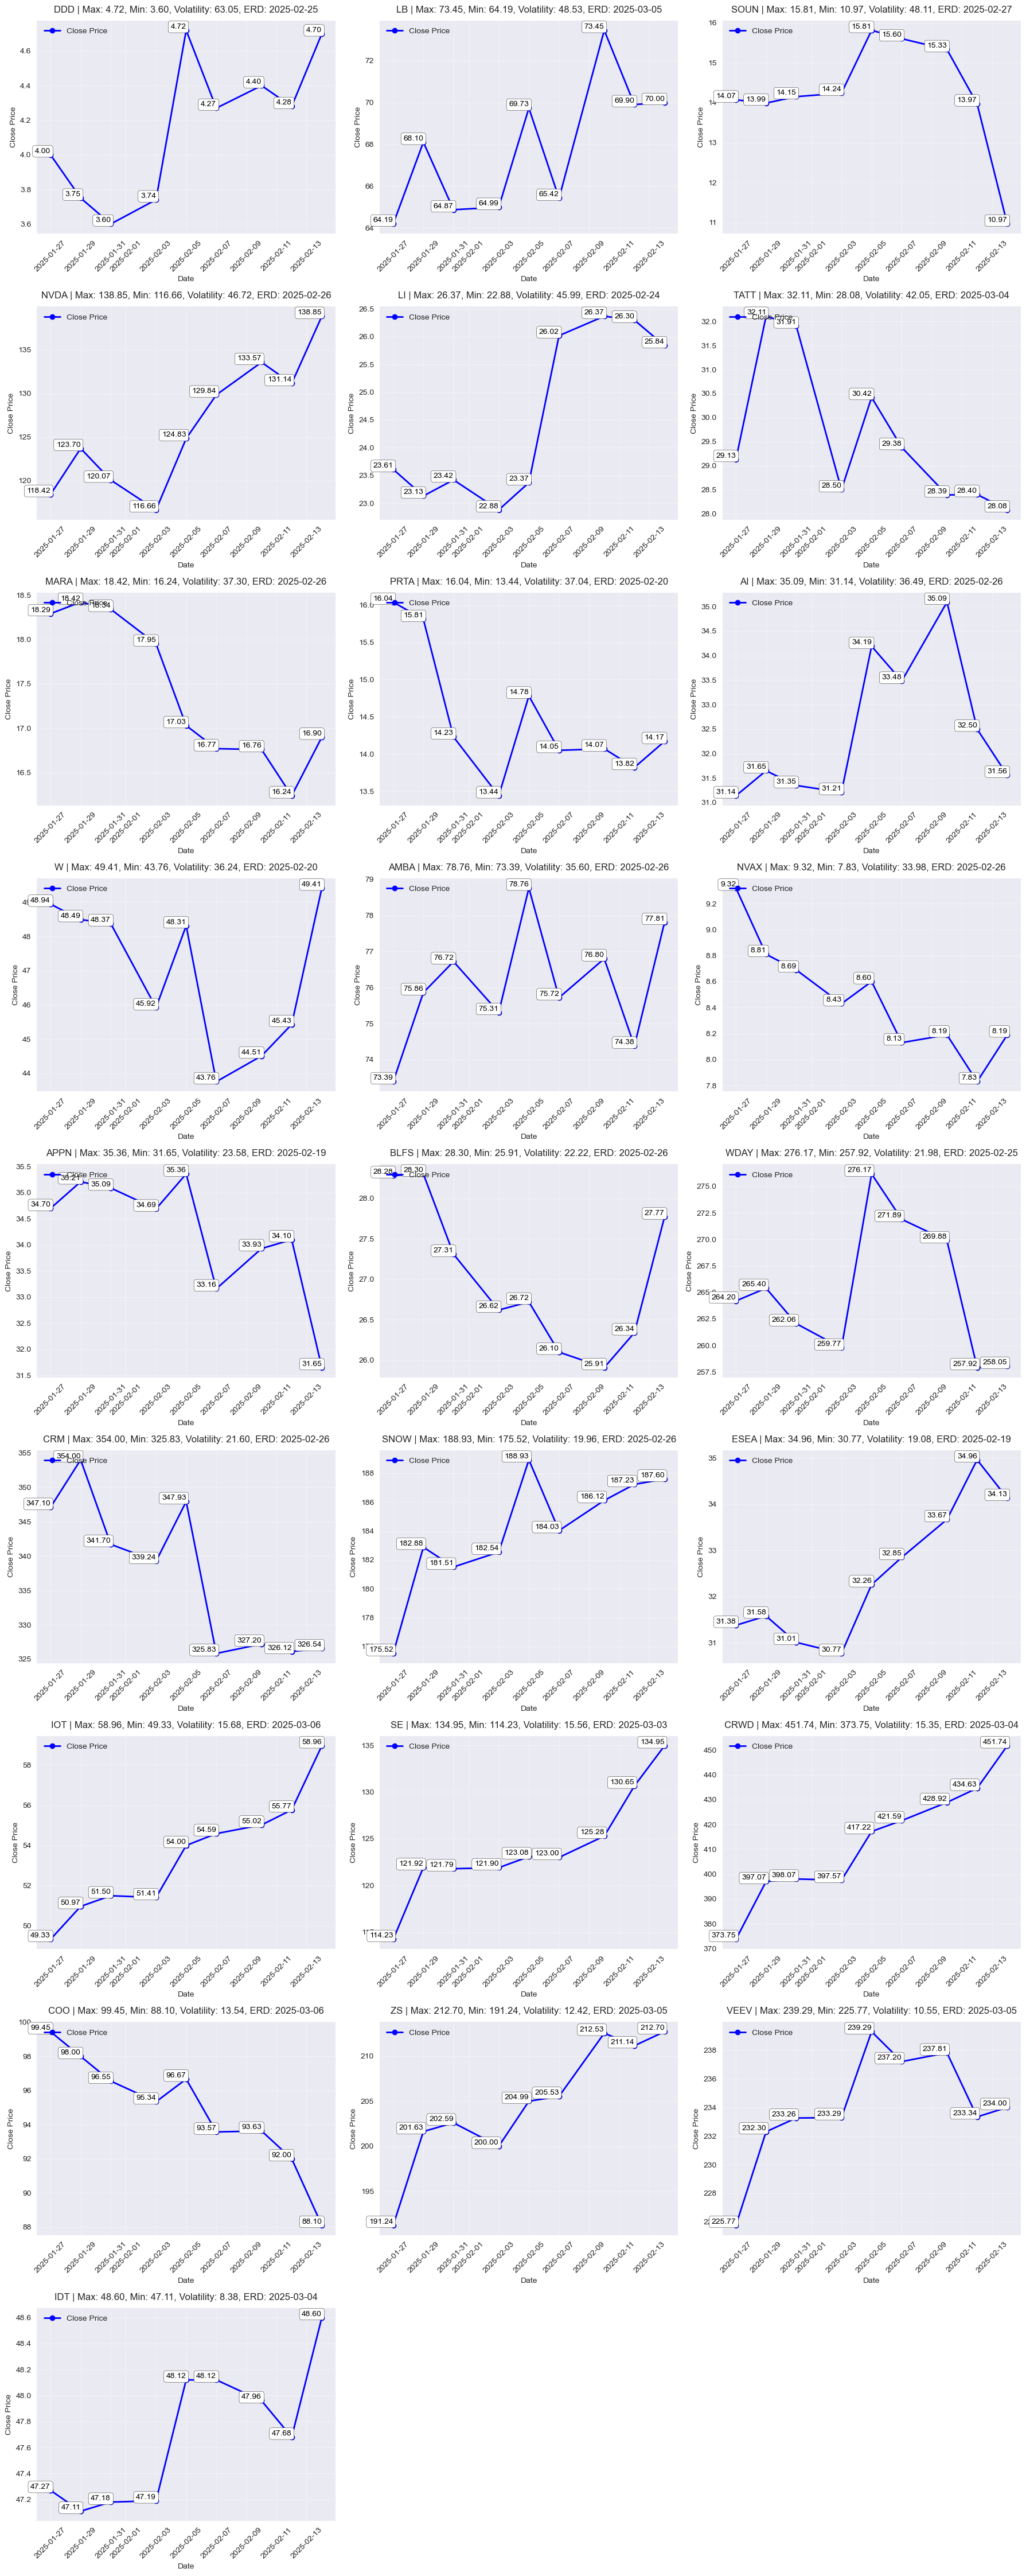

In [216]:
fig = create_stock_price_grid(pandas_df, top_25_stocks)
plt.show()